**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approx](03_quadratic_laplace_approximation.ipynb) | ⏭️ Next: [Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics](05_mcmc_production_diagnostics.ipynb)**

---

# Sheet 4: First Principles — Metropolis-Hastings MCMC Mechanics from Scratch
### *Sampling Complex Posteriors When Quadratic Approximations Fail*

In Sheet 3, Quadratic Approximation assumed the log-posterior is parabolic (Gaussian). But when posteriors are skewed, heavily bounded, or multimodal, Gaussian approximations fail.

In this sheet, we build **Markov Chain Monte Carlo (MCMC)** completely from scratch using the **Metropolis-Hastings algorithm**. You will master the mathematics of detailed balance, the 3-step proposal/acceptance rule, diagnose step-size tuning failure modes, and inspect autocorrelation decay.

---

# Sheet 3: The Mechanics of MCMC: How Random Walks Find Truth
### *The Pure First-Principles Bridge (Zero External Libraries)*

In **Sheet 1**, we saw that Grid Approximation cannot scale past 3 parameters. In **Sheet 2**, we saw that Quadratic Approximation scales to many parameters but assumes a symmetric Gaussian bell curve, failing on skewed or complex geometries.

Now, we arrive at the crown jewel of modern Bayesian computation: **Markov Chain Monte Carlo (MCMC)**.

This notebook builds an MCMC engine from absolute first principles using **pure Base R (zero libraries)**. You will discover how a blind, memoryless random walker can explore an arbitrary parameter space and guarantee convergence to the exact posterior distribution.

---

## Table of Contents
1. **Part 1: The Intuition — King Markov and the Island Kingdom**
2. **Part 2: The Core Mathematics of Metropolis-Hastings**
   - **Deep Dive 1**: The Cancellation of the Intractable Denominator $P(y)$
   - **Deep Dive 2**: Detailed Balance & Stationary Distributions (The Proof of Convergence)
   - **Deep Dive 3**: The 3-Step Metropolis Algorithm (Propose $\to$ Ratio $\to$ Stochastic Decision)
3. **Part 3: 1D Metropolis from Scratch in Pure Base R**
   - Implementing `metropolis_step()` and `run_mcmc()`
   - Traceplot, Running Mean & Posterior Histogram
4. **Part 4: The Step-Size ($\tau$) Dilemma & Tuning Failure Modes**
   - Mode 1: Step Size Too Small (Sluggish Diffusion & High Autocorrelation)
   - Mode 2: Step Size Too Large (Frozen Flatlines in Probability Deserts)
   - Mode 3: Optimal Step Size (Gelman's 23.4% – 44% Rule & Healthy Mixing)
5. **Part 5: Autocorrelation, Markov Memory Decay & Effective Sample Size ($ESS$)**
   - **Deep Dive 4**: What is Autocorrelation in MCMC?
   - Inspecting Decay via `acf()`
   - Effective Sample Size ($ESS$) Formula
   - The Truth About Thinning (When is it Useful?)
6. **Part 6: Joint 2D Metropolis from Scratch: Estimating Mean ($\mu$) and Spread ($\sigma$)**
   - Joint 2D Random Walk on Adult Heights
   - Comparing Grid vs. Laplace vs. MCMC Posteriors
7. **Part 7: The Curse of Volume & The Need for Hamiltonian Monte Carlo (HMC)**
8. **Part 8: Hands-On Challenge Exercises**

## Part 1: The Intuition — King Markov and the Island Kingdom

Imagine a benevolent monarch—**King Markov**—ruling an archipelago of islands arranged in a circle. Each island has a different population:
- Island 1 has 1,000 citizens.
- Island 2 has 2,000 citizens.
- Island 7 has 7,000 citizens.

The King wants to spend his time visiting each island in **exact proportion to its population** (spending 7 times as much time on Island 7 as on Island 1). However, the King is blindfolded, has no map of the kingdom, and does not know the total population of all islands combined.

### The King's Daily Protocol:
Every day, King Markov uses a simple rule:
1. **Flip a coin** to choose a neighboring island to visit (left or right).
2. **Send a royal scout** to measure the population of the candidate island ($P_{\text{prop}}$) and compare it to current island ($P_{\text{curr}}$).
3. **The Decision Rule**:
   - If the candidate island has **more people** ($P_{\text{prop}} > P_{\text{curr}}$), the King **always moves** there!
   - If the candidate island has **fewer people**, he moves with probability $\alpha = \frac{P_{\text{prop}}}{P_{\text{curr}}}$. He spins a wheel of fortune: with probability $\alpha$ he moves; otherwise, he stays put and drinks tea for another day on his current island.

> **The Miracle**: Over a year of recording his daily location, the King's visit history will match the island populations **with 100% mathematical precision**—without ever knowing the total population of the kingdom!

## Part 2: The Core Mathematics of Metropolis-Hastings

### Deep Dive 1: Cancellation of the Intractable Denominator

Recall Bayes' Theorem:
$$P(\theta \mid y) = \frac{\mathcal{L}(y \mid \theta) P(\theta)}{P(y)} = \frac{\mathcal{L}(y \mid \theta) P(\theta)}{\int \mathcal{L}(y \mid \theta) P(\theta) \, d\theta}$$

In higher dimensions, calculating the evidence integral $P(y) = \int \mathcal{L} \cdot P \, d\theta$ is practically impossible. But in the Metropolis algorithm, we only evaluate the **ratio** of posterior probabilities between proposed $\theta^*$ and current $\theta^{(t)}$:

$$\frac{P(\theta^* \mid y)}{P(\theta^{(t)} \mid y)} = \frac{\frac{\mathcal{L}(y \mid \theta^*) P(\theta^*)}{P(y)}}{\frac{\mathcal{L}(y \mid \theta^{(t)}) P(\theta^{(t)})}{P(y)}} = \frac{\mathcal{L}(y \mid \theta^*) P(\theta^*)}{\mathcal{L}(y \mid \theta^{(t)}) P(\theta^{(t)})}$$

> **The Normalizing Constant $P(y)$ Cancels Completely!** We only ever need to evaluate the unnormalized posterior: Likelihood $\times$ Prior.

---

### Deep Dive 2: Detailed Balance & The Stationary Distribution

Why is the posterior distribution guaranteed to be the stationary equilibrium of this chain?

A Markov chain reaches a stationary distribution $\pi(\theta)$ if the probability flow between every pair of states $A$ and $B$ is in exact equilibrium (**Detailed Balance**):
$$\pi(A) \cdot T(A \to B) = \pi(B) \cdot T(B \to A)$$
where $T(A \to B)$ is the transition probability from state $A$ to state $B$.

With symmetric proposal distribution $q(A \to B) = q(B \to A)$ (e.g. Gaussian centered at current position):
$$T(A \to B) = q(A \to B) \cdot \min\left(1, \frac{\pi(B)}{\pi(A)}\right)$$

Multiplying by $\pi(A)$:
$$\pi(A) T(A \to B) = q(A \to B) \cdot \min(\pi(A), \pi(B)) = q(B \to A) \cdot \min(\pi(B), \pi(A)) = \pi(B) T(B \to A)$$

Because detailed balance holds identically for all states, the posterior distribution $P(\theta \mid y)$ is the **unique, invariant stationary distribution** of the Markov chain.

---

### Deep Dive 3: The 3-Step Metropolis Algorithm

At iteration $t$ with current parameter state $\theta^{(t)}$:
1. **Propose**: Generate candidate $\theta^* \sim \text{Normal}(\theta^{(t)}, \tau^2)$, where $\tau$ is the proposal step size.
2. **Calculate Acceptance Ratio $\alpha$ in Log-Space**:
   $$\log \alpha = \min\Big(0, \; \log P(\theta^* \mid y) - \log P(\theta^{(t)} \mid y)\Big)$$
3. **Stochastic Decision (Coin Flip)**: Draw random uniform $u \sim \text{Uniform}(0, 1)$:
   - If $\log(u) < \log \alpha$ $\implies$ **ACCEPT**: Set $\theta^{(t+1)} = \theta^*$.
   - If $\log(u) \ge \log \alpha$ $\implies$ **REJECT**: Set $\theta^{(t+1)} = \theta^{(t)}$ *(stay in place and record the old value again!)*.

> **Crucial Rule**: When a proposal is rejected, you **must re-record the current position** in your chain. Rejections are not discarded; they represent regions of low probability that the chain must not enter, ensuring the correct density weighting!

## Part 3: 1D Metropolis from Scratch in Pure Base R

Let us test our first-principles walker on estimating population mean height $\mu$, assuming known $\sigma = 8.0$ for clear 1D visualization.

=== 1D MCMC Run Results (Pure Base R) ===


Total Steps:     4000


Acceptance Rate: 52.2%


Posterior Mean:  172.24 cm (Discarding first 500 warmup steps)


Posterior SD:    1.123 cm


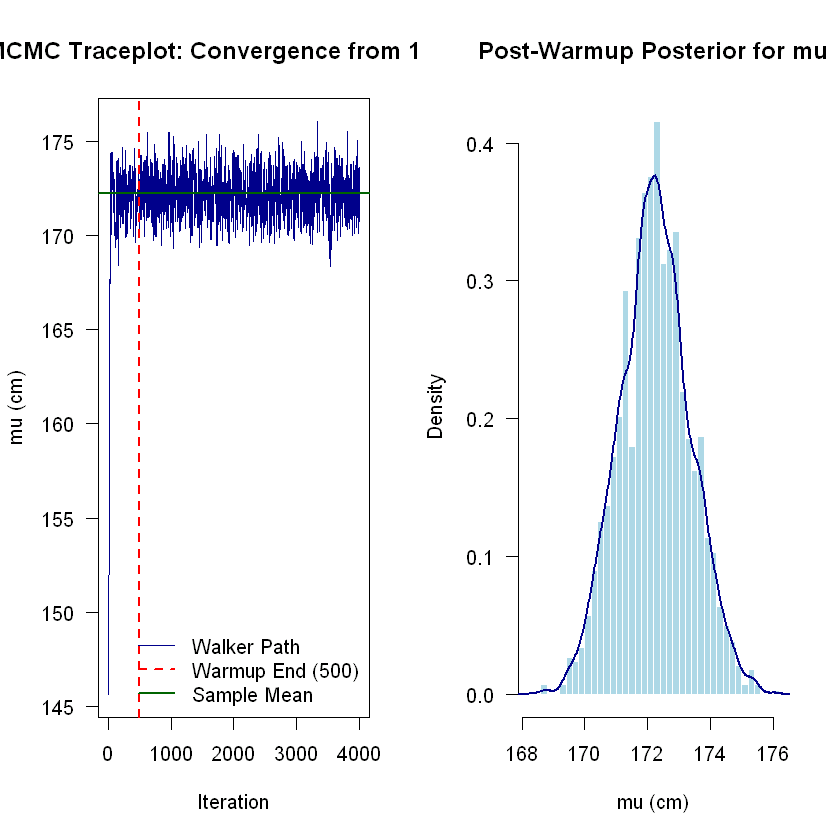

In [1]:
set.seed(42)
n <- 50
heights <- rnorm(n, mean = 172.5, sd = 8.0)

# Target unnormalized log-posterior for mu
target_log_posterior_mu <- function(mu) {
  # Likelihood: sum of log dnorm
  log_lik <- sum(dnorm(heights, mean = mu, sd = 8.0, log = TRUE))
  # Prior: mu ~ Normal(170, 15)
  log_prior <- dnorm(mu, mean = 170, sd = 15, log = TRUE)
  return(log_lik + log_prior)
}

# Single Metropolis Step
metropolis_step <- function(current_mu, step_size = 2.0) {
  # Step 1: Propose
  proposed_mu <- current_mu + rnorm(1, mean = 0, sd = step_size)
  
  # Step 2: Ratio in log-space
  log_alpha <- target_log_posterior_mu(proposed_mu) - target_log_posterior_mu(current_mu)
  
  # Step 3: Coin flip
  if (log(runif(1)) < log_alpha) {
    return(list(mu = proposed_mu, accepted = TRUE))
  } else {
    return(list(mu = current_mu,  accepted = FALSE))
  }
}

# Run full Markov Chain
run_1d_mcmc <- function(n_steps = 4000, start_mu = 145, step_size = 2.0) {
  samples  <- numeric(n_steps)
  accepted <- 0
  curr     <- start_mu
  
  for (t in 1:n_steps) {
    step <- metropolis_step(curr, step_size = step_size)
    if (step$accepted) accepted <- accepted + 1
    curr <- step$mu
    samples[t] <- curr
  }
  
  return(list(samples = samples, accept_rate = accepted / n_steps))
}

# Execute walker starting far away at mu = 145 cm
fit_mcmc <- run_1d_mcmc(n_steps = 4000, start_mu = 145, step_size = 2.0)

cat("=== 1D MCMC Run Results (Pure Base R) ===\n")
cat(sprintf("Total Steps:     %d\n", length(fit_mcmc$samples)))
cat(sprintf("Acceptance Rate: %.1f%%\n", fit_mcmc$accept_rate * 100))
cat(sprintf("Posterior Mean:  %.2f cm (Discarding first 500 warmup steps)\n", 
            mean(fit_mcmc$samples[501:4000])))
cat(sprintf("Posterior SD:    %.3f cm\n", sd(fit_mcmc$samples[501:4000])))

# Visual inspection: Traceplot & Posterior Distribution
par(mfrow = c(1, 2))
plot(fit_mcmc$samples, type = "l", col = "darkblue", lwd = 1, las = 1,
     main = "MCMC Traceplot: Convergence from 145cm", xlab = "Iteration", ylab = "mu (cm)")
abline(v = 500, col = "red", lty = 2, lwd = 2) # Warmup threshold
abline(h = mean(heights), col = "darkgreen", lwd = 2)
legend("bottomright", legend = c("Walker Path", "Warmup End (500)", "Sample Mean"),
       col = c("darkblue", "red", "darkgreen"), lty = c(1, 2, 1), lwd = c(1, 2, 2), bty = "n")

hist(fit_mcmc$samples[501:4000], breaks = 30, col = "lightblue", border = "white", freq = FALSE,
     main = "Post-Warmup Posterior for mu", xlab = "mu (cm)", las = 1)
lines(density(fit_mcmc$samples[501:4000]), col = "darkblue", lwd = 2)
par(mfrow = c(1, 1))

## Part 4: The Step-Size ($\tau$) Dilemma & Tuning Failure Modes

The performance of a Metropolis sampler depends entirely on the proposal step size $\tau$:

1. **Step Size Too Small ($\tau = 0.1$)**: The proposal $\theta^*$ is so close to $\theta^{(t)}$ that $P(\theta^*) \approx P(\theta^{(t)})$, yielding an acceptance rate $> 95\%$. But the walker barely moves! It behaves like sluggish diffusion (high autocorrelation, slow exploration).
2. **Step Size Too Large ($\tau = 35.0$)**: The candidate $\theta^*$ lands far out in the low-probability tails. Almost every proposal is rejected ($< 2\%$ acceptance rate). The walker remains stuck on flatlines for hundreds of steps at a time.
3. **Optimal Step Size ($\tau = 2.5$)**: Balances exploration and acceptance, producing Gelman's optimal acceptance rate ($\sim 23.4\% - 44\%$ for random-walk Metropolis).

Let us simulate all three regimes side-by-side to witness these failure modes:

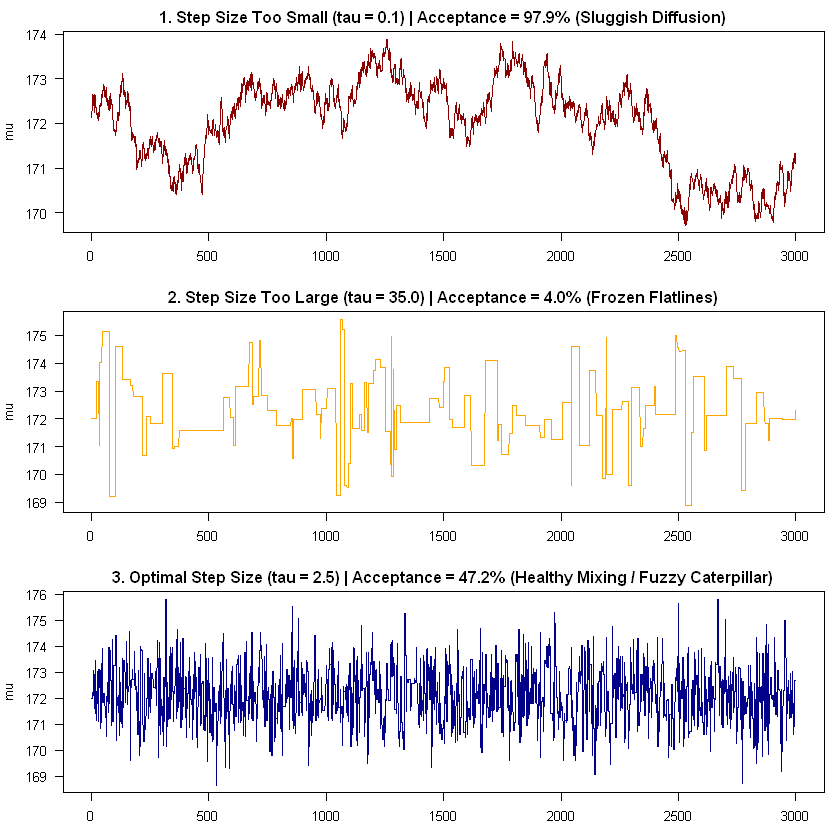

In [2]:
set.seed(42)
chain_tiny  <- run_1d_mcmc(3000, start_mu = 172, step_size = 0.1)
chain_huge  <- run_1d_mcmc(3000, start_mu = 172, step_size = 35.0)
chain_ideal <- run_1d_mcmc(3000, start_mu = 172, step_size = 2.5)

par(mfrow = c(3, 1), mar = c(3, 4, 2, 1))
plot(chain_tiny$samples, type = "l", col = "darkred", las = 1,
     main = sprintf("1. Step Size Too Small (tau = 0.1) | Acceptance = %.1f%% (Sluggish Diffusion)", 
                    chain_tiny$accept_rate * 100), ylab = "mu")
plot(chain_huge$samples, type = "l", col = "orange", las = 1,
     main = sprintf("2. Step Size Too Large (tau = 35.0) | Acceptance = %.1f%% (Frozen Flatlines)", 
                    chain_huge$accept_rate * 100), ylab = "mu")
plot(chain_ideal$samples, type = "l", col = "darkblue", las = 1,
     main = sprintf("3. Optimal Step Size (tau = 2.5) | Acceptance = %.1f%% (Healthy Mixing / Fuzzy Caterpillar)", 
                    chain_ideal$accept_rate * 100), ylab = "mu")
par(mfrow = c(1, 1))

## Part 5: Autocorrelation, Markov Memory Decay & Effective Sample Size ($ESS$)

### Deep Dive 4: What is Autocorrelation in Markov Chains?

In Grid approximation (Sheet 1) or Laplace approximation (Sheet 2), every sample drawn is **statistically independent (i.i.d.)**. If you draw 10,000 samples, you have 10,000 completely independent pieces of information.

In MCMC, consecutive samples are **dependent** because $\theta^{(t+1)}$ starts where $\theta^{(t)}$ was. The **Autocorrelation at lag $k$** measures this memory:
$$\rho_k = \text{Cor}\left(\theta^{(t)}, \theta^{(t+k)}\right)$$

- In a healthy chain, $\rho_k$ decays exponentially to 0 as lag $k$ increases.
- In a sluggish chain (small step size), $\rho_k$ remains high even at lag 30!

### Effective Sample Size ($ESS$)
Due to autocorrelation, $N = 3000$ MCMC iterations does **not** equal 3000 independent samples. The **Effective Sample Size ($ESS$)** tells you how many independent samples your chain is worth:
$$ESS = \frac{N}{1 + 2 \sum_{k=1}^\infty \rho_k}$$

Let us plot the autocorrelation functions (`acf()`) and compute the $ESS$ for our small vs optimal chains:

=== Effective Sample Size (ESS) Comparison (N = 3000 total iterations) ===


Small Step (tau = 0.1):  Lag-1 Cor = 0.995 | Approx ESS = 8 (Massive information loss!)


Optimal Step (tau = 2.5): Lag-1 Cor = 0.600 | Approx ESS = 751 (High information efficiency!)


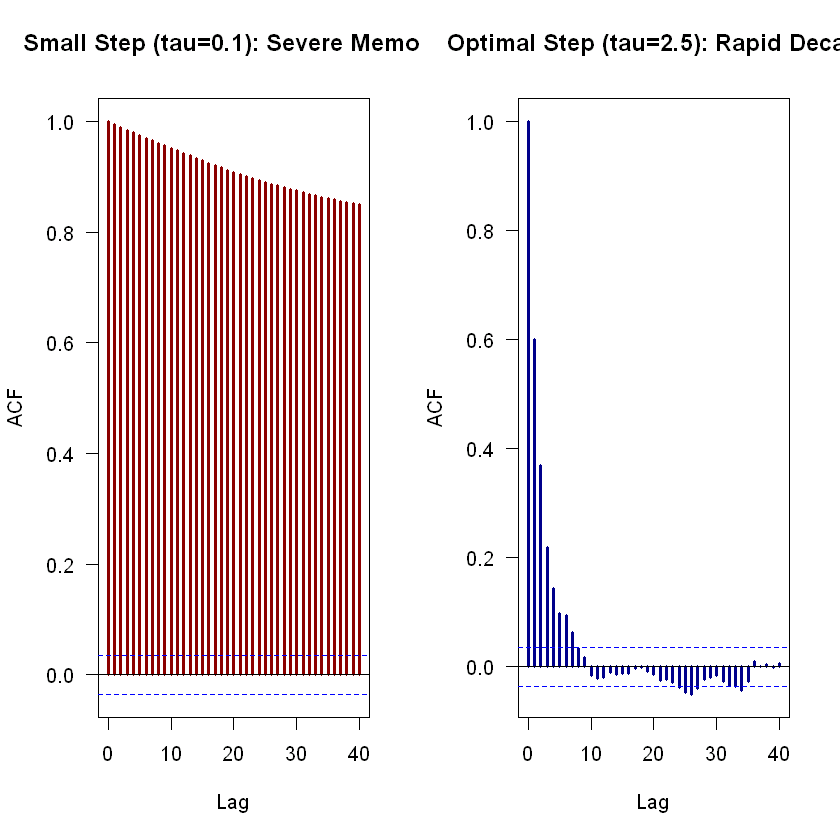

In [3]:
par(mfrow = c(1, 2))
acf(chain_tiny$samples, lag.max = 40, col = "darkred", lwd = 2.5, las = 1,
    main = "Small Step (tau=0.1): Severe Memory")
acf(chain_ideal$samples, lag.max = 40, col = "darkblue", lwd = 2.5, las = 1,
    main = "Optimal Step (tau=2.5): Rapid Decay")
par(mfrow = c(1, 1))

# Estimate approximate ESS based on lag-1 autocorrelation: N * (1 - rho1) / (1 + rho1)
rho1_tiny  <- acf(chain_tiny$samples, lag.max = 1, plot = FALSE)$acf[2]
rho1_ideal <- acf(chain_ideal$samples, lag.max = 1, plot = FALSE)$acf[2]

ess_tiny  <- length(chain_tiny$samples) * (1 - rho1_tiny) / (1 + rho1_tiny)
ess_ideal <- length(chain_ideal$samples) * (1 - rho1_ideal) / (1 + rho1_ideal)

cat("=== Effective Sample Size (ESS) Comparison (N = 3000 total iterations) ===\n")
cat(sprintf("Small Step (tau = 0.1):  Lag-1 Cor = %.3f | Approx ESS = %d (Massive information loss!)\n", 
            rho1_tiny, round(ess_tiny)))
cat(sprintf("Optimal Step (tau = 2.5): Lag-1 Cor = %.3f | Approx ESS = %d (High information efficiency!)\n", 
            rho1_ideal, round(ess_ideal)))

## Part 6: Joint 2D Metropolis from Scratch: Estimating Mean ($\mu$) and Spread ($\sigma$)

Now let us expand our Base R sampler to jointly explore the 2D parameter space $(\mu, \sigma)$ simultaneously without any external packages!

=== 2D Metropolis-Hastings Results (Post-Warmup) ===


Acceptance Rate:       84.0%


Posterior Mean (mu):   172.34 cm (SD: 1.349 cm)


Posterior Mean (sigma):9.30 cm (SD: 0.927 cm)


95% Credible (mu):     [169.67, 174.98] cm


95% Credible (sigma):  [7.68, 11.24] cm


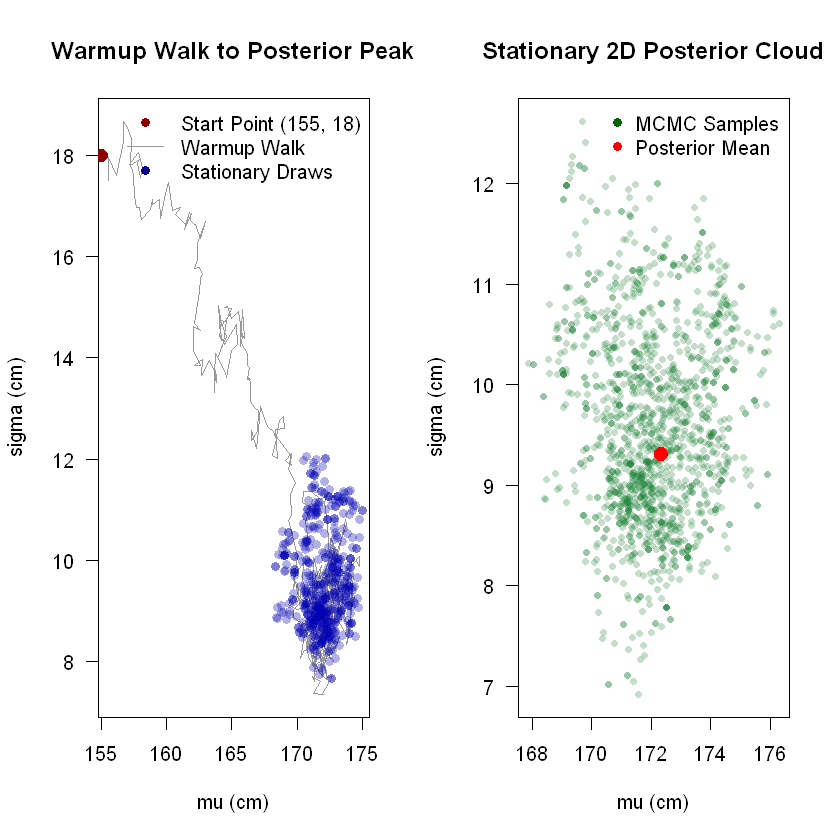

In [4]:
set.seed(42)

# Joint Log-Posterior for (mu, sigma)
joint_log_post <- function(mu, sigma) {
  if (sigma <= 0 || sigma >= 30) return(-Inf)
  log_lik   <- sum(dnorm(heights, mean = mu, sd = sigma, log = TRUE))
  log_prior <- dnorm(mu, mean = 170, sd = 15, log = TRUE) + dunif(sigma, 0, 30, log = TRUE)
  return(log_lik + log_prior)
}

# 2D Random Walk Metropolis
run_2d_mcmc <- function(n_steps = 6000, start_mu = 160, start_sigma = 15, step_sizes = c(0.4, 0.3)) {
  chain <- matrix(NA, nrow = n_steps, ncol = 2)
  colnames(chain) <- c("mu", "sigma")
  
  mu    <- start_mu
  sigma <- start_sigma
  curr_log_p <- joint_log_post(mu, sigma)
  accepts <- 0
  
  for (t in 1:n_steps) {
    # Propose bivariate step
    prop_mu    <- mu + rnorm(1, 0, step_sizes[1])
    prop_sigma <- sigma + rnorm(1, 0, step_sizes[2])
    
    prop_log_p <- joint_log_post(prop_mu, prop_sigma)
    log_alpha  <- prop_log_p - curr_log_p
    
    if (log(runif(1)) < log_alpha) {
      mu         <- prop_mu
      sigma      <- prop_sigma
      curr_log_p <- prop_log_p
      accepts    <- accepts + 1
    }
    chain[t, ] <- c(mu, sigma)
  }
  
  return(list(chain = chain, accept_rate = accepts / n_steps))
}

fit_2d <- run_2d_mcmc(n_steps = 8000, start_mu = 155, start_sigma = 18)
post_samples <- fit_2d$chain[1001:8000, ] # Discard 1000 warmup steps

cat("=== 2D Metropolis-Hastings Results (Post-Warmup) ===\n")
cat(sprintf("Acceptance Rate:       %.1f%%\n", fit_2d$accept_rate * 100))
cat(sprintf("Posterior Mean (mu):   %.2f cm (SD: %.3f cm)\n", mean(post_samples[, "mu"]), sd(post_samples[, "mu"])))
cat(sprintf("Posterior Mean (sigma):%.2f cm (SD: %.3f cm)\n", mean(post_samples[, "sigma"]), sd(post_samples[, "sigma"])))
cat(sprintf("95%% Credible (mu):     [%.2f, %.2f] cm\n", quantile(post_samples[, "mu"], 0.025), quantile(post_samples[, "mu"], 0.975)))
cat(sprintf("95%% Credible (sigma):  [%.2f, %.2f] cm\n", quantile(post_samples[, "sigma"], 0.025), quantile(post_samples[, "sigma"], 0.975)))

# Visualizing 2D Trajectory and Joint Posterior
par(mfrow = c(1, 2))
plot(fit_2d$chain[1:500, "mu"], fit_2d$chain[1:500, "sigma"], type = "l", col = "gray60", las = 1,
     main = "Warmup Walk to Posterior Peak", xlab = "mu (cm)", ylab = "sigma (cm)")
points(155, 18, col = "darkred", pch = 19, cex = 1.4)
points(post_samples[1:500, "mu"], post_samples[1:500, "sigma"], col = rgb(0, 0, 0.7, 0.3), pch = 16)
legend("topright", legend = c("Start Point (155, 18)", "Warmup Walk", "Stationary Draws"), 
       col = c("darkred", "gray60", "darkblue"), pch = c(19, NA, 16), lty = c(NA, 1, NA), bty = "n")

plot(post_samples[1:1500, "mu"], post_samples[1:1500, "sigma"], 
     col = rgb(0.1, 0.5, 0.2, 0.25), pch = 16, cex = 0.8, las = 1,
     main = "Stationary 2D Posterior Cloud", xlab = "mu (cm)", ylab = "sigma (cm)")
points(mean(post_samples[, "mu"]), mean(post_samples[, "sigma"]), col = "red", pch = 19, cex = 1.5)
legend("topright", legend = c("MCMC Samples", "Posterior Mean"), col = c("darkgreen", "red"), pch = c(16, 19), bty = "n")
par(mfrow = c(1, 1))

## Part 7: The Curse of Volume & The Leap to Hamiltonian Monte Carlo (HMC)

Our from-scratch Random Walk Metropolis worked beautifully for 2 parameters. But as we scale to modern scientific models (100–10,000 parameters), random walks suffer from a catastrophic geometric bottleneck called **the curse of volume**.

- In high dimensions, random walks almost always step in directions that **drop off the typical set** into near-zero probability space, forcing acceptance rates to drop to zero unless step sizes are microscopically small.
- Exploring a high-dimensional space with random walk diffusion requires $O(D^2)$ steps—it takes forever!

### The Solution: Sheet 4 and Hamiltonian Monte Carlo (Stan)
In **Sheet 4**, we replace blind random walks with **Hamiltonian Monte Carlo (HMC)**. Instead of staggering around blindly like a drunkard, HMC treats the negative log-posterior like a physical bowl and launches a frictionless particle that glides effortlessly along the contours of the typical set using Newton's laws of motion!

## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): The Acceptance Rate Goldilocks Zone
> **Question**: You implement a Metropolis-Hastings sampler for a multi-parameter posterior:
> - Run A has an acceptance rate of **$94\%$**.
> - Run B has an acceptance rate of **$28\%$**.
> - Run C has an acceptance rate of **$2\%$**.
> 
> Which run is operating in the optimal efficiency zone? Why is an acceptance rate of $94\%$ actually a failure mode rather than a sign of success?

In [ ]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
# Compare three MCMC runs:
# Run A: 94% acceptance
# Run B: 28% acceptance
# Run C: 2% acceptance

# 1. Which run is operating in the optimal efficiency zone?
optimal_run <- NA  # "A", "B", or "C"

# 2. What is the danger of Run A (94%)? Explain in comments:


<details>
<summary><b>🔍 Click here to view the solution & Gelman efficiency theorem</b></summary>

**Answer**:
**Run B ($28\%$) is optimal.** (Theoretical optimal for random walk Metropolis is $\sim 23.4\%$ for multidimensional targets, and $\sim 44\%$ for 1D).

**Why 94% is a failure mode**:
An acceptance rate of $94\%$ occurs when the proposal step size $\sigma_{\text{prop}}$ is microscopic. The sampler accepts almost every move because the candidate is virtually identical to the current point. 
However, it takes millions of tiny steps to cross the posterior distribution, resulting in **extreme autocorrelation, glacial exploration speed, and an Effective Sample Size ($ESS$) near zero**. Run C ($2\%$), conversely, proposes massive leaps into the empty tails that are almost always rejected.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Evaluating the Metropolis Acceptance Rule
> **Scenario**: The current state of your Markov chain is $\theta^{(t)} = 175\text{ cm}$, with unnormalized posterior value $p(\theta^{(t)} \mid D) = 0.040$. 
> Your symmetric Gaussian proposal generates candidate $\theta^* = 178\text{ cm}$, with unnormalized posterior value $p(\theta^* \mid D) = 0.010$.
> 1. Calculate the exact acceptance probability $\alpha(\theta^{(t)}, \theta^*)$.
> 2. If a random draw $u \sim \text{Uniform}(0, 1)$ yields $u = 0.42$, is the candidate accepted or rejected?
> 3. What is the value of $\theta^{(t+1)}$ at the next step?

In [ ]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
theta_curr <- 175.0
p_curr <- 0.040

theta_cand <- 178.0
p_cand <- 0.010

u_draw <- 0.42

# 1. Compute acceptance probability alpha:
# alpha <- ...

# 2. Decide if accepted:
# is_accepted <- u_draw < alpha

# 3. Next state theta^(t+1):
# theta_next <- if (is_accepted) theta_cand else theta_curr

# cat(sprintf("Alpha: %.2f | Accepted? %s | Next state: %.1f\n", alpha, is_accepted, theta_next))


<details>
<summary><b>🔍 Click here to view the solution & step execution</b></summary>

**Calculation**:
1. Under symmetric proposal $q(\theta^* \mid \theta) = q(\theta \mid \theta^*)$:
   $$\alpha(\theta^{(t)}, \theta^*) = \min\left(1, \frac{p(\theta^* \mid D)}{p(\theta^{(t)} \mid D)}\right) = \min\left(1, \frac{0.010}{0.040}\right) = \min(1, 0.25) = 0.25$$
2. Since $u = 0.42 > \alpha = 0.25$, **the proposed candidate is REJECTED**.
3. **Next State**: The chain does not move. It duplicates the current state:
   $$\theta^{(t+1)} = \theta^{(t)} = 175\text{ cm}$$

```r
p_curr <- 0.040
p_cand <- 0.010
alpha <- min(1.0, p_cand / p_curr)
cat(sprintf('Acceptance Probability alpha: %.2f (25%% chance of accepting)\n', alpha))
```
</details>

---

### 🔴 Tier 3 (Production Challenge): The Hastings Ratio for Asymmetric Proposals
> **Scenario**: Suppose you are estimating a variance parameter $\sigma > 0$ strictly constrained to positive values. Instead of a symmetric normal walk, you propose moves using a Log-Normal distribution centered at the current value:
> $$\theta^* \sim \text{LogNormal}(\log \theta^{(t)}, \tau^2)$$
> 1. Why does the standard Metropolis ratio $\frac{p(\theta^* \mid D)}{p(\theta^{(t)} \mid D)}$ fail to preserve the true target distribution?
> 2. What is the **Hastings correction factor**, and how does it guarantee detailed balance?

In [ ]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
theta_curr <- 2.0
theta_cand <- 5.0
tau <- 0.5

# Density of jumping from 2.0 -> 5.0 vs 5.0 -> 2.0 under Log-Normal:
# q_forward <- dlnorm(theta_cand, meanlog = log(theta_curr), sdlog = tau)
# q_reverse <- dlnorm(theta_curr, meanlog = log(theta_cand), sdlog = tau)

# Compute the Hastings correction ratio: q(theta_curr | theta_cand) / q(theta_cand | theta_curr)
# hastings_ratio <- ...
# cat(sprintf("Hastings Ratio: %.4f\n", hastings_ratio))


<details>
<summary><b>🔍 Click here to view the mathematical proof</b></summary>

**Mathematical Proof**:
1. **Asymmetry Violation**: In a Log-Normal distribution, the probability density of jumping from small to large is not equal to jumping from large to small:
   $$q(\theta^* \mid \theta) = \frac{1}{\theta^* \tau \sqrt{2\pi}} \exp\left(-\frac{(\log \theta^* - \log \theta)^2}{2\tau^2}\right)$$
   Notice the denominator has $\theta^*$, whereas $q(\theta \mid \theta^*)$ has $\theta$ in the denominator! Thus $q(\theta^* \mid \theta) \neq q(\theta \mid \theta^*)$. If you use the standard Metropolis rule, the chain will artificially drift toward larger values because jumps upward are inherently favored.
2. **Hastings Correction**: To satisfy detailed balance $\pi(\theta) q(\theta^* \mid \theta) \alpha(\theta, \theta^*) = \pi(\theta^*) q(\theta \mid \theta^*) \alpha(\theta^*, \theta)$, Hastings introduced the transition ratio correction:
   $$\alpha(\theta, \theta^*) = \min\left(1, \frac{p(\theta^* \mid D)}{p(\theta \mid D)} \times \frac{q(\theta \mid \theta^*)}{q(\theta^* \mid \theta)}\right)$$
   For the Log-Normal proposal, the exponential terms cancel, leaving the elegant ratio:
   $$\frac{q(\theta \mid \theta^*)}{q(\theta^* \mid \theta)} = \frac{\theta^*}{\theta}$$
   Multiplying by $\frac{\theta^*}{\theta}$ penalizes upward jumps and encourages downward moves, exactly restoring time-reversibility.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approx](03_quadratic_laplace_approximation.ipynb) | ⏭️ Next: [Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics](05_mcmc_production_diagnostics.ipynb)**